In [1]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
data_path = "tweets-data\sentiment-france.csv"
prepro_data_path = "tweets-data\hasilpreprocess-france.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_14644\1087236396.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-france.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_14644\1087236396.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-france.csv"


In [3]:
data = pd.read_csv(data_path)

In [4]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893722819000742213,Sun Feb 23 18:01:18 +0000 2025,0,Quand tu sors de Manchester United t es destin...,1893722819000742213,NaN,NaN,fr,NaN,0,0,0,https://x.com/kenzo1_2/status/1893722819000742213,896438157545267200,kenzo1_2
1,1893721833968374163,Sun Feb 23 17:57:23 +0000 2025,0,Wesh mais depuis que Antony est parti de Manch...,1893721833968374163,https://pbs.twimg.com/tweet_video_thumb/GkfZ-B...,NaN,fr,NaN,0,0,0,https://x.com/Zola243_/status/1893721833968374163,1582162760800124928,Zola243_
2,1893720072708845880,Sun Feb 23 17:50:23 +0000 2025,0,Joyeux anniversaire à l infatigable Casemiro. ...,1893720072708845880,https://pbs.twimg.com/amplify_video_thumb/1630...,NaN,fr,NaN,0,0,0,https://x.com/senegal_mu/status/18937200727088...,1160685392074596352,senegal_mu
3,1893720986039574934,Sun Feb 23 17:54:01 +0000 2025,1,Continue sur cette lancée p tit. Content pour ...,1893720986039574934,NaN,NaN,fr,"Lyon, France",0,0,0,https://x.com/BHD0601/status/1893720986039574934,1200236304203730944,BHD0601
4,1893719895386292727,Sun Feb 23 17:49:41 +0000 2025,0,C est quoi ce cirque ? https://t.co/T8LhzfxhZk,1893719895386292727,https://pbs.twimg.com/amplify_video_thumb/1893...,NaN,fr,NaN,0,0,0,https://x.com/senegal_mu/status/18937198953862...,1160685392074596352,senegal_mu


In [5]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,Quand tu sors de Manchester United t es destin...,kenzo1_2,Sun Feb 23 18:01:18 +0000 2025
1,Wesh mais depuis que Antony est parti de Manch...,Zola243_,Sun Feb 23 17:57:23 +0000 2025
2,Joyeux anniversaire à l infatigable Casemiro. ...,senegal_mu,Sun Feb 23 17:50:23 +0000 2025
3,Continue sur cette lancée p tit. Content pour ...,BHD0601,Sun Feb 23 17:54:01 +0000 2025
4,C est quoi ce cirque ? https://t.co/T8LhzfxhZk,senegal_mu,Sun Feb 23 17:49:41 +0000 2025
...,...,...,...
1000,@XaviSol_ Barça vs Liverpool/ Tottenham vs Man...,Msqueunclub1,Sat Feb 22 03:23:52 +0000 2025
1001,@AmorimEra_ @business Le problème de Mancheste...,souleym36494195,Sat Feb 22 01:52:42 +0000 2025
1002,C'est jour de match ! | Everton - Manchester ...,MUFR_,Sat Feb 22 00:53:24 +0000 2025
1003,JOUR DE MATCH ! #MUFC https://t.co/RZB16kpKWH,senegal_mu,Sat Feb 22 00:45:15 +0000 2025


# 1. Cleaning Data

In [6]:
df.shape

(1005, 3)

In [7]:
df = df.drop_duplicates(subset=['full_text'])

In [8]:
df.duplicated().sum()

0

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [11]:
df.shape

(1001, 3)

In [12]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [13]:
df['full_text'] = df['full_text'].str.lower()

In [14]:
df

,full_text,username,created_at
0,quand tu sors de manchester united t es destin...,kenzo1_2,Sun Feb 23 18:01:18 +0000 2025
1,wesh mais depuis que antony est parti de manch...,Zola243_,Sun Feb 23 17:57:23 +0000 2025
2,joyeux anniversaire l infatigable casemiro 33 ...,senegal_mu,Sun Feb 23 17:50:23 +0000 2025
3,continue sur cette lance p tit content pour toi,BHD0601,Sun Feb 23 17:54:01 +0000 2025
4,c est quoi ce cirque,senegal_mu,Sun Feb 23 17:49:41 +0000 2025
...,...,...,...
1000,bara vs liverpool tottenham vs manchester united,Msqueunclub1,Sat Feb 22 03:23:52 +0000 2025
1001,le problme de manchester united cest ni les jo...,souleym36494195,Sat Feb 22 01:52:42 +0000 2025
1002,cest jour de match everton manchester united 2...,MUFR_,Sat Feb 22 00:53:24 +0000 2025
1003,jour de match,senegal_mu,Sat Feb 22 00:45:15 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [15]:
# Normalisasi

norm = {
    "t es": "tu es", "c est": "ce est", "j suis": "je suis", "j ai": "je ai", "j étais": "je étais",
    "j avais": "je avais", "p tit": "petit", "ptit": "petit", "wesh": "", "bcp": "beaucoup",
    "pq": "pourquoi", "pcq": "parce que", "qd": "quand", "jms": "jamais", "stp": "s'il te plaît",
    "svp": "s'il vous plaît", "mtn": "maintenant", "qlq": "quelque", "qlqs": "quelques", "tkt": "t'inquiète",
    "tkt pas": "ne t'inquiète pas", "mdr": "(rire)", "ptdr": "(rire intense)", "lol": "(rire)", "bg": "beau gosse", "tg": "tais-toi"
}

def normalisasi(str_text):
    for i in norm:
        str_text = str_text.replace(i, norm[i])
    return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text,username,created_at
0,quand tu sors de manchester united tu es desti...,kenzo1_2,Sun Feb 23 18:01:18 +0000 2025
1,mais depuis que antony est parti de mancheste...,Zola243_,Sun Feb 23 17:57:23 +0000 2025
2,joyeux anniversaire l infatigable casemiro 33 ...,senegal_mu,Sun Feb 23 17:50:23 +0000 2025
3,continue sur cette lance petit content pour toi,BHD0601,Sun Feb 23 17:54:01 +0000 2025
4,ce est quoi ce cirque,senegal_mu,Sun Feb 23 17:49:41 +0000 2025
...,...,...,...
1000,bara vs liverpool tottenham vs manchester united,Msqueunclub1,Sat Feb 22 03:23:52 +0000 2025
1001,le problme de manchester united cest ni les jo...,souleym36494195,Sat Feb 22 01:52:42 +0000 2025
1002,cest jour de match everton manchester united 2...,MUFR_,Sat Feb 22 00:53:24 +0000 2025
1003,jour de match,senegal_mu,Sat Feb 22 00:45:15 +0000 2025


In [16]:
# Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

manual_stop_words = [
    "alors", "au", "aucuns", "aussi", "autre", "avant", "avec", "avoir", "bon", 
    "car", "ce", "cela", "ces", "ceux", "chaque", "ci", "comme", "comment", 
    "dans", "des", "du", "dedans", "dehors", "depuis", "devrait", "doit", 
    "donc", "dos", "droite", "début", "elle", "elles", "en", "encore", "essai", 
    "est", "et", "eu", "fait", "faites", "fois", "font", "hors", "ici", "il", 
    "ils", "je", "juste", "la", "le", "les", "leur", "là", "ma", "maintenant", 
    "mais", "mes", "mine", "moins", "mon", "mot", "même", "ni", "nommés", "notre", 
    "nous", "ou", "où", "par", "parce", "parole", "pas", "personnes", "peut", 
    "pièce", "plupart", "pour", "pourquoi", "quand", "que", "quel", "quelle", 
    "quelles", "quels", "qui", "sa", "sans", "ses", "seulement", "si", "sien", 
    "son", "sont", "sous", "soyez", "sujet", "sur", "ta", "tandis", "tellement", 
    "tels", "tes", "ton", "tous", "tout", "trop", "très", "tu", "voient", "vont", 
    "votre", "vous", "vu", "ça", "étaient", "état", "étions", "été", "être"
]

nltk_stop_words = set(stopwords.words('french'))
custom_stop_words = nltk_stop_words.union(set(manual_stop_words))

def remove_stopwords_manual(str_text):
    words = str_text.split()
    filtered_words = [word for word in words if word.lower() not in manual_stop_words]
    return " ".join(filtered_words)

df['full_text'] = df['full_text'].apply(remove_stopwords_manual)

df[['full_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,full_text
0,sors de manchester united es destin un grand a...
1,antony parti de manchester united devenu meill...
2,joyeux anniversaire l infatigable casemiro 33 ...
3,continue cette lance petit content toi
4,quoi cirque
...,...
1000,bara vs liverpool tottenham vs manchester united
1001,problme de manchester united cest joueurs lent...
1002,cest jour de match everton manchester united 2...
1003,jour de match


In [17]:
# Tokenize
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

0       [sors, de, manchester, united, es, destin, un,...
1       [antony, parti, de, manchester, united, devenu...
2       [joyeux, anniversaire, l, infatigable, casemir...
3           [continue, cette, lance, petit, content, toi]
4                                          [quoi, cirque]
                              ...                        
1000    [bara, vs, liverpool, tottenham, vs, mancheste...
1001    [problme, de, manchester, united, cest, joueur...
1002    [cest, jour, de, match, everton, manchester, u...
1003                                    [jour, de, match]
1004    [une, victoire, aujourd, hui, s, plat, bien, c...
Name: full_text, Length: 1001, dtype: object

In [18]:
import nltk
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['full_text'] = df['full_text'].apply(stemming)
tokenized.to_csv(prepro_data_path, index=False)
data = pd.read_csv(prepro_data_path, encoding='latin1')


# 3. Labeling

In [19]:
data

,full_text
0,"['sors', 'de', 'manchester', 'united', 'es', '..."
1,"['antony', 'parti', 'de', 'manchester', 'unite..."
2,"['joyeux', 'anniversaire', 'l', 'infatigable',..."
3,"['continue', 'cette', 'lance', 'petit', 'conte..."
4,"['quoi', 'cirque']"
...,...
996,"['bara', 'vs', 'liverpool', 'tottenham', 'vs',..."
997,"['problme', 'de', 'manchester', 'united', 'ces..."
998,"['cest', 'jour', 'de', 'match', 'everton', 'ma..."
999,"['jour', 'de', 'match']"


In [20]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 81
Netral = 895
Negatif = 25

Total Data : 1001


In [22]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['sors', 'de', 'manchester', 'united', 'es', '...",Positif
1,"['antony', 'parti', 'de', 'manchester', 'unite...",Netral
2,"['joyeux', 'anniversaire', 'l', 'infatigable',...",Netral
3,"['continue', 'cette', 'lance', 'petit', 'conte...",Netral
4,"['quoi', 'cirque']",Netral
...,...,...
996,"['bara', 'vs', 'liverpool', 'tottenham', 'vs',...",Netral
997,"['problme', 'de', 'manchester', 'united', 'ces...",Netral
998,"['cest', 'jour', 'de', 'match', 'everton', 'ma...",Netral
999,"['jour', 'de', 'match']",Netral


# 4. Visualisasi

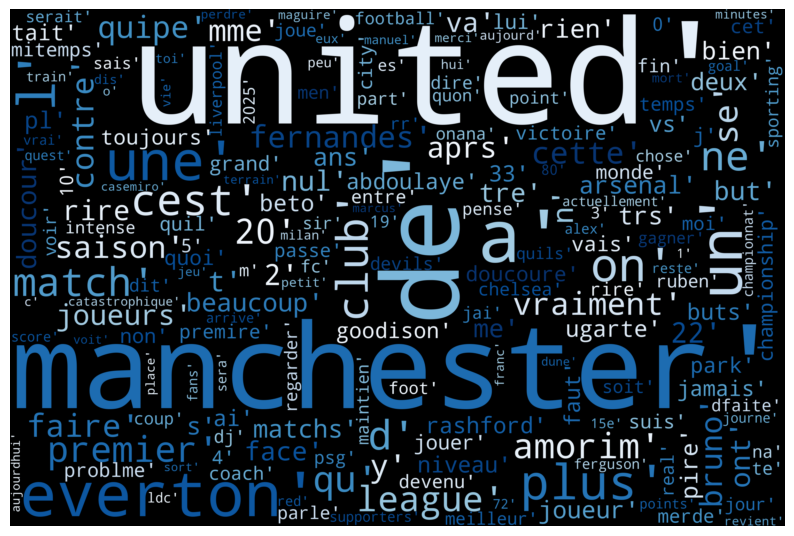

In [23]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

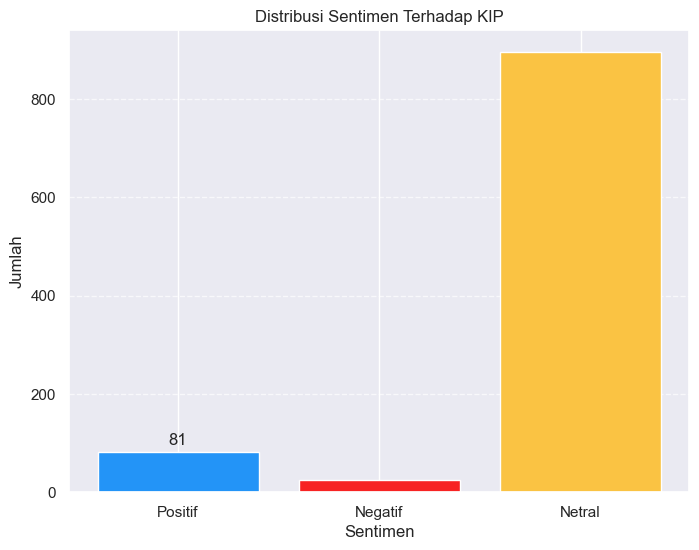

In [24]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Multinomial Naive Bayes

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [26]:
data.head()

,full_text,klasifikasi
0,"['sors', 'de', 'manchester', 'united', 'es', '...",Positif
1,"['antony', 'parti', 'de', 'manchester', 'unite...",Netral
2,"['joyeux', 'anniversaire', 'l', 'infatigable',...",Netral
3,"['continue', 'cette', 'lance', 'petit', 'conte...",Netral
4,"['quoi', 'cirque']",Netral


In [27]:
data.shape

(1001, 2)

In [28]:
data.klasifikasi.unique()

array(['Positif', 'Netral', 'Negatif'], dtype=object)

In [29]:
data.klasifikasi.value_counts()

klasifikasi
Netral     895
Positif     81
Negatif     25
Name: count, dtype: int64

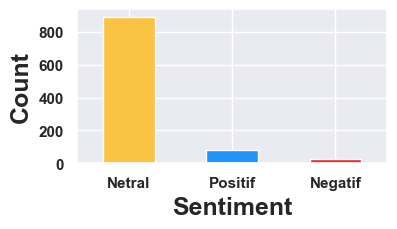

In [30]:
data.klasifikasi.value_counts().plot(kind='bar', figsize=(4, 2), rot=0, color=['#fac343', '#2394f7', '#f72323'])
plt.xlabel('Sentiment', fontweight='bold', fontsize=18)
plt.ylabel('Count', fontweight='bold', fontsize=18)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold');

In [31]:
labelencoder = LabelEncoder()
data['Target'] = labelencoder.fit_transform(data['klasifikasi'])

In [32]:
data.Target.unique()

array([2, 1, 0])

In [33]:
X = data.full_text
y = data.Target

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [35]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 201, 800, 201)

In [36]:
clf = Pipeline([
    ('cv', CountVectorizer()),
    ('mnb', MultinomialNB(force_alpha=False))
])

In [37]:
clf.fit(X_train, y_train)

Pipeline(steps=[('cv', CountVectorizer()),
                ('mnb', MultinomialNB(force_alpha=False))])

In [38]:
print('Accuracy on the test set:', round(clf.score(X_test, y_test), 4))

Accuracy on the test set: 0.8806


In [39]:
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=clf.classes_)

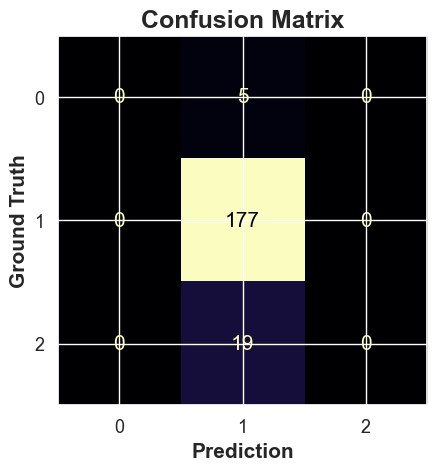

In [40]:

disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [41]:
cat_labels = ['negative', 'neutral', 'positive']
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=cat_labels)

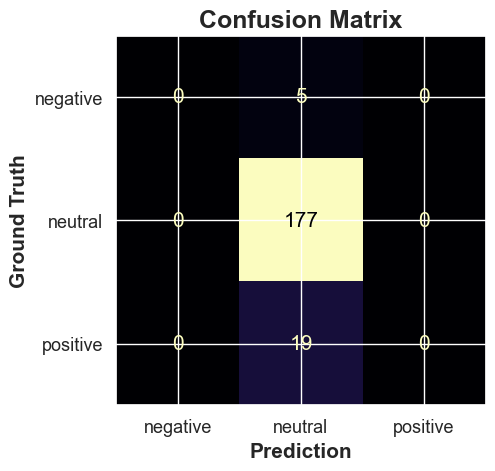

In [42]:
disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [43]:
print('F1 score:', round(metrics.f1_score(y_test, y_pred, average='micro'), 4))

F1 score: 0.8806


In [44]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.88      1.00      0.94       177
           2       0.00      0.00      0.00        19

    accuracy                           0.88       201
   macro avg       0.29      0.33      0.31       201
weighted avg       0.78      0.88      0.82       201



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

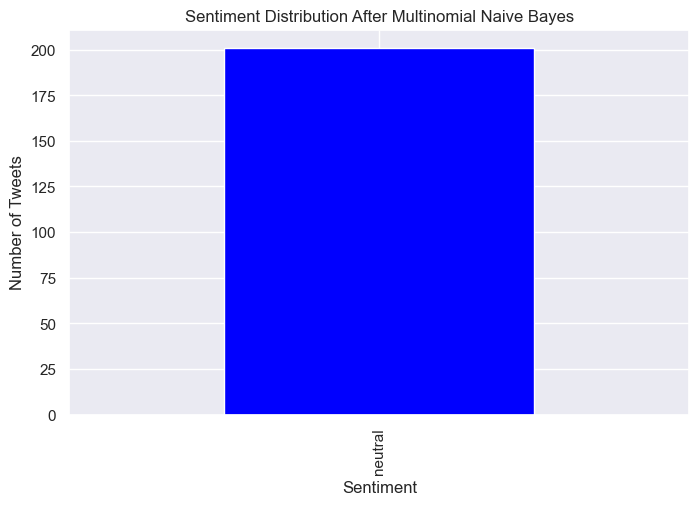

In [45]:
df_result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_result['Predicted'] = df_result['Predicted'].map(label_mapping)

sentiment_count = df_result['Predicted'].value_counts()

plt.figure(figsize=(8,5))
sentiment_count.plot(kind='bar', color=['blue', 'red', 'yellow'])
plt.title('Sentiment Distribution After Multinomial Naive Bayes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()